# Week 9 Companion: Training MobileNetV2 From Scratch — The Control Experiment

## Why this notebook exists

In the live session we claimed: *"With only 500 images, training from scratch fails. Transfer learning is the answer."* Then we showed transfer learning working — but we never actually showed training from scratch failing. That's an experiment with no control group.

This notebook runs the control. **Same architecture. Same 500 flower images. Same test set.** The only variable we change is where the weights come from.

| Experiment | Starting weights | Trainable | Epochs |
|---|---|---|---|
| **A** | Random (`weights=None`) | ALL 2.3M parameters | 30 |
| **B** | Random + data augmentation | ALL 2.3M parameters | 30 |
| **C** | ImageNet (`weights='imagenet'`), frozen base | only the ~6K-param head | 10 |

Notice the handicap: the from-scratch runs get **3× more epochs** than transfer learning. We're giving "from scratch" every chance to win.

**Before running anything, write down your prediction:** what test accuracy will Experiment A reach? (Random guessing on 5 classes = 20%. The live session's transfer model hit ~90%.)

⏱️ **Runtime warning:** the two from-scratch runs train all 2.3M parameters for 30 epochs each. Expect ~15–30 minutes on a laptop GPU (MPS / RTX 2000), a few minutes on an L4.

In [1]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import torch

keras.utils.set_random_seed(42)

SCRATCH_EPOCHS = 30   # experiments A and B (from scratch)
TRANSFER_EPOCHS = 10  # experiment C (pretrained, frozen base) — same as the live session

print('MPS:', getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available())
print('XPU:', hasattr(torch, 'xpu') and torch.xpu.is_available())
print('CUDA:', torch.cuda.is_available())

MPS: True
XPU: False
CUDA: False


## Section 1: Load the same dataset as the live session

Identical loader, identical data: the 5-class Oxford Flowers subset — 500 training images (100 per class), 100 test images. If `./flowers` is missing, build it with `instructor_materials/organize_oxford_flowers.py`.

In [2]:
# Same loader as week9_live_session.ipynb — 5-class Oxford Flowers subset.
import pathlib
from PIL import Image

DATA_DIR = './flowers'  # adjust to wherever your flowers/ folder lives
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def load_split(split):
    """Read flowers/<split>/<class>/*.jpg into (images, labels) NumPy arrays.

    Class index is the alphabetical position of the folder name, so the same
    class_names ordering is shared by train and test.
    """
    root = pathlib.Path(DATA_DIR) / split
    classes = sorted(d.name for d in root.iterdir() if d.is_dir())
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        for img_path in sorted((root / cls).glob('*.jpg')):
            img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
            images.append(np.asarray(img, dtype='float32'))  # HWC, [0, 255]
            labels.append(label_idx)
    return np.array(images), np.array(labels), classes

X_train, y_train, class_names = load_split('train')
X_test, y_test, _ = load_split('test')

print(f'Classes: {class_names}')
print(f'Train: {X_train.shape[0]} images | Test: {X_test.shape[0]} images')

Classes: ['foxglove', 'passion_flower', 'petunia', 'rose', 'water_lily']
Train: 500 images | Test: 100 images


## Section 2: Experiment A — full MobileNetV2, random weights

The build below is **one word away** from the live session's: `weights=None` instead of `weights='imagenet'`. Same 154 layers, same architecture — but every weight starts as random noise. Nothing about edges, textures, petals, or anything else.

Two deliberate differences from the transfer-learning setup, both consequences of starting from scratch:
- **Nothing is frozen.** There are no pretrained features to protect — all 2.3M parameters must be learned from our 500 images.
- **No `training=False` on the base call.** In the live session that flag kept BatchNorm layers using their ImageNet statistics. Here there are no ImageNet statistics — BatchNorm must learn everything from our data, so it runs in normal training mode.

⚠️ **One adjustment we have to make for from-scratch training (see the loop in the next cell):** MobileNetV2's BatchNorm layers ship with `momentum=0.999` — a default tuned for ImageNet-scale training, where the running mean/variance that BatchNorm uses *at evaluation time* has hundreds of thousands of steps to settle. Our whole run is only 480 steps (16 batches × 30 epochs). At momentum 0.999 those running statistics never catch up, and the model scores **exactly 20% (chance)** at test time no matter what it learned during training. We lower it to 0.9 so evaluation reflects what the network actually learned. Even the *defaults* of this architecture assume big data — from-scratch training doesn't just need more images, it needs its whole configuration rethought.

In [3]:
# The ONLY substantive change from the live session: weights=None (random init)
scratch_base = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights=None
)
# scratch_base.trainable is True by default — we train ALL of it

# BatchNorm momentum 0.999 → 0.9: at 16 steps/epoch the eval-time running
# statistics would never converge and test accuracy would be stuck at chance
# (see the markdown above)
for layer in scratch_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.momentum = 0.9

# Same head as the live session: GlobalAveragePooling2D + Dropout + Dense(5)
inputs = keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = scratch_base(x)  # no training=False: BatchNorm must learn from OUR data
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

scratch_model = keras.Model(inputs, outputs, name='MobileNetV2_Scratch')
scratch_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
scratch_model.summary()

Model: "MobileNetV2_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 2,230,277 (8.51 MB)

 Non-trainable params: 34,112 (133.25 KB)

**Look at the trainable parameter count: ~2.26M** — versus about 6,400 in the live session's frozen-base model. That's roughly **350× more parameters to learn**, from the same 500 images. Put another way: one training image for every ~4,500 trainable parameters. Keep that ratio in mind while the next cell runs.

In [4]:
scratch_history = scratch_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=SCRATCH_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

scratch_test_acc = scratch_model.evaluate(X_test, y_test, verbose=0)[1]
print(f'\nExperiment A (from scratch) test accuracy: {scratch_test_acc:.4f}')
# Expected: training accuracy climbs toward 100%, test accuracy stalls far below —
# the model memorizes 500 images instead of learning what flowers look like.

Epoch 1/30


16/16 - 5s - 301ms/step - accuracy: 0.4220 - loss: 1.4902 - val_accuracy: 0.2000 - val_loss: 2.4940


Epoch 2/30


16/16 - 5s - 293ms/step - accuracy: 0.5600 - loss: 1.0880 - val_accuracy: 0.2000 - val_loss: 3.1790


Epoch 3/30


...

Epoch 29/30


16/16 - 7s - 460ms/step - accuracy: 0.9280 - loss: 0.1954 - val_accuracy: 0.6800 - val_loss: 1.1424


Epoch 30/30


16/16 - 7s - 468ms/step - accuracy: 0.9560 - loss: 0.1130 - val_accuracy: 0.7200 - val_loss: 1.0920



Experiment A (from scratch) test accuracy: 0.7200


### Read the curves before scrolling on

Look at the gap between the two lines below. Training accuracy keeps climbing — the network has more than enough capacity to **memorize** 500 images. Validation accuracy stalls and wobbles far below it. Memorization is not generalization, and no amount of extra epochs fixes it: the information about what makes a rose a rose simply isn't extractable from 100 examples by 2.3M randomly-initialized parameters.

(Two artifacts you may notice: validation sits at chance for the first few epochs while BatchNorm's running statistics settle, and it keeps bouncing around afterward — with this little data, every weight update swings the decision boundaries. Compare that to the smooth, stable validation curve you got in the live session.)

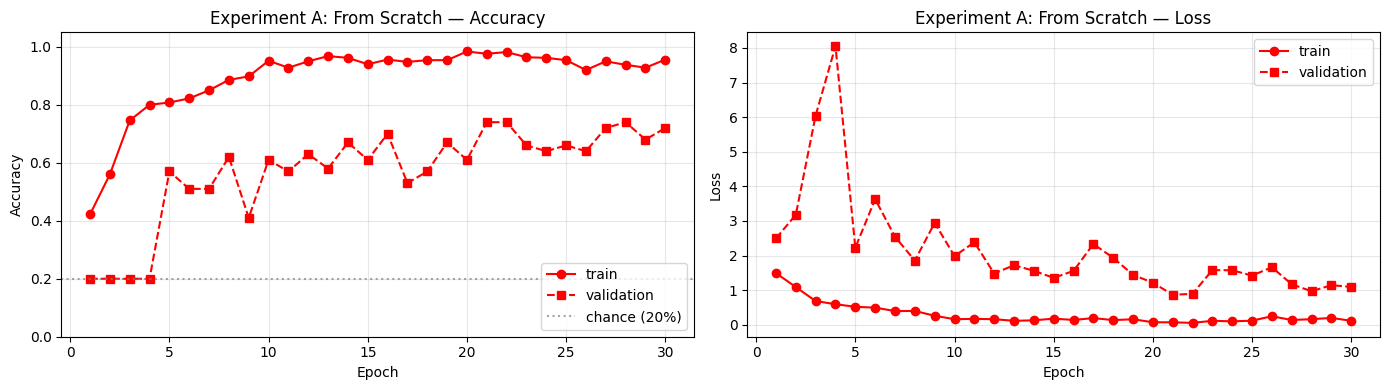

In [5]:
epochs_a = range(1, len(scratch_history.history['accuracy']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(epochs_a, scratch_history.history['accuracy'], 'r-o', label='train')
axes[0].plot(epochs_a, scratch_history.history['val_accuracy'], 'r--s', label='validation')
axes[0].axhline(0.2, color='gray', linestyle=':', alpha=0.7, label='chance (20%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Experiment A: From Scratch — Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_a, scratch_history.history['loss'], 'r-o', label='train')
axes[1].plot(epochs_a, scratch_history.history['val_loss'], 'r--s', label='validation')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Experiment A: From Scratch — Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Section 3: Experiment B — "maybe it just needs augmentation?"

Fair objection. In the live session, data augmentation helped fine-tuning — maybe it can rescue from-scratch training too? Augmentation effectively multiplies the dataset with flipped/rotated/zoomed variants.

So: fresh random weights, same 30 epochs, plus the **exact augmentation pipeline from the live session**.

In [6]:
# Same augmentation as the live session's Phase 2
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Fresh random-weight base — Experiment B starts from scratch too
scratch_aug_base = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights=None
)
# Same BatchNorm momentum fix as Experiment A
for layer in scratch_aug_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.momentum = 0.9

inputs = keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)  # only active during training
x = preprocess_input(x)
x = scratch_aug_base(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

scratch_aug_model = keras.Model(inputs, outputs, name='MobileNetV2_Scratch_Aug')
scratch_aug_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

scratch_aug_history = scratch_aug_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=SCRATCH_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

scratch_aug_test_acc = scratch_aug_model.evaluate(X_test, y_test, verbose=0)[1]
print(f'\nExperiment B (from scratch + augmentation) test accuracy: {scratch_aug_test_acc:.4f}')
# Expected: augmentation helps a lot more than you might guess — but watch how
# volatile the validation curve is, and what the result costs vs Experiment C.

Epoch 1/30


16/16 - 9s - 574ms/step - accuracy: 0.2960 - loss: 1.6858 - val_accuracy: 0.2000 - val_loss: 2.3193


Epoch 2/30


16/16 - 9s - 565ms/step - accuracy: 0.4060 - loss: 1.4554 - val_accuracy: 0.2000 - val_loss: 3.3346


Epoch 3/30


...

Epoch 29/30


16/16 - 6s - 345ms/step - accuracy: 0.9180 - loss: 0.2504 - val_accuracy: 0.8600 - val_loss: 0.7109


Epoch 30/30


16/16 - 5s - 341ms/step - accuracy: 0.9420 - loss: 0.1659 - val_accuracy: 0.9100 - val_loss: 0.2198



Experiment B (from scratch + augmentation) test accuracy: 0.9100


## Section 4: Experiment C — the pretrained control

Now the exact recipe from the live session's Phase 1: **same architecture, same head, same data** — but the base starts from ImageNet weights and stays frozen. Only the ~6K-parameter head trains, and it only gets **10 epochs** (a third of what we gave the from-scratch runs).

In [7]:
# Live-session Phase 1 recipe: pretrained base, frozen, train only the head
pretrained_base = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)
pretrained_base.trainable = False

inputs = keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)
x = pretrained_base(x, training=False)  # keep BatchNorm in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(len(class_names), activation='softmax')(x)

transfer_model = keras.Model(inputs, outputs, name='MobileNetV2_Pretrained_Frozen')
transfer_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

transfer_history = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=TRANSFER_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=2
)

transfer_test_acc = transfer_model.evaluate(X_test, y_test, verbose=0)[1]
print(f'\nExperiment C (pretrained, frozen base) test accuracy: {transfer_test_acc:.4f}')

Epoch 1/10


16/16 - 1s - 76ms/step - accuracy: 0.5100 - loss: 1.2287 - val_accuracy: 0.8700 - val_loss: 0.5793


Epoch 2/10


16/16 - 1s - 77ms/step - accuracy: 0.8920 - loss: 0.4329 - val_accuracy: 0.9600 - val_loss: 0.2550


Epoch 3/10


...

Epoch 9/10


16/16 - 1s - 75ms/step - accuracy: 0.9880 - loss: 0.0592 - val_accuracy: 0.9800 - val_loss: 0.0704


Epoch 10/10


16/16 - 1s - 75ms/step - accuracy: 0.9900 - loss: 0.0498 - val_accuracy: 0.9900 - val_loss: 0.0680



Experiment C (pretrained, frozen base) test accuracy: 0.9900


## Section 5: The verdict — one plot

Left: validation accuracy per epoch for all three runs. Right: final test accuracy. Remember the pretrained run stops at epoch 10 because it doesn't *need* more — in the run below it beat Experiment A's *final* score after one epoch, and Experiment B's after two.

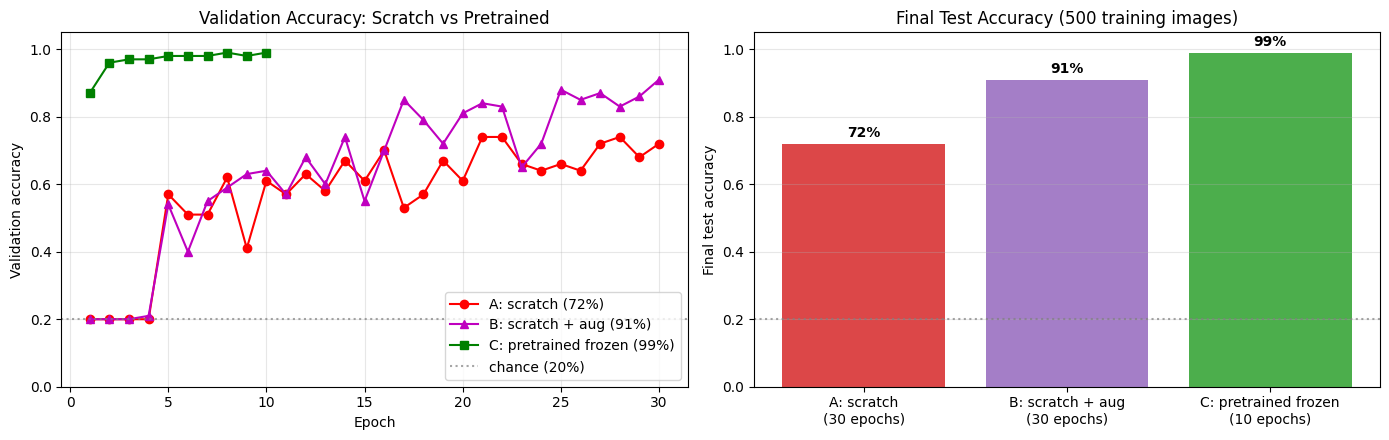

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

epochs_b = range(1, len(scratch_aug_history.history['val_accuracy']) + 1)
epochs_c = range(1, len(transfer_history.history['val_accuracy']) + 1)

axes[0].plot(epochs_a, scratch_history.history['val_accuracy'], 'r-o',
             label=f'A: scratch ({scratch_test_acc:.0%})')
axes[0].plot(epochs_b, scratch_aug_history.history['val_accuracy'], 'm-^',
             label=f'B: scratch + aug ({scratch_aug_test_acc:.0%})')
axes[0].plot(epochs_c, transfer_history.history['val_accuracy'], 'g-s',
             label=f'C: pretrained frozen ({transfer_test_acc:.0%})')
axes[0].axhline(0.2, color='gray', linestyle=':', alpha=0.7, label='chance (20%)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Validation accuracy'); axes[0].set_ylim(0, 1.05)
axes[0].set_title('Validation Accuracy: Scratch vs Pretrained'); axes[0].legend(); axes[0].grid(alpha=0.3)

names = ['A: scratch\n(30 epochs)', 'B: scratch + aug\n(30 epochs)', 'C: pretrained frozen\n(10 epochs)']
accs = [scratch_test_acc, scratch_aug_test_acc, transfer_test_acc]
bars = axes[1].bar(names, accs, color=['tab:red', 'tab:purple', 'tab:green'], alpha=0.85)
axes[1].axhline(0.2, color='gray', linestyle=':', alpha=0.7)
axes[1].set_ylabel('Final test accuracy'); axes[1].set_ylim(0, 1.05)
axes[1].set_title('Final Test Accuracy (500 training images)')
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width() / 2, acc + 0.02, f'{acc:.0%}',
                 ha='center', fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

## Wrap-up: what the control experiment proves

Same architecture, same data, same test set. The only real variable was the starting weights — and it changed everything.

**Why from-scratch fails here:**
1. **The arithmetic is brutal.** 2.3M trainable parameters, 500 images — one image per ~4,500 parameters. The network can memorize the training set (watch train accuracy push past 95%) but can't infer the general concept of each flower from 100 examples.
2. **What ImageNet actually buys you.** The pretrained base already learned edges, textures, color blobs, and object parts from 1.4M images. Our 500 images then only need to teach a 6K-parameter head *which combinations of those features* mean "foxglove." That's a learnable problem at this data scale.
3. **Augmentation is real leverage — but look at what it costs and where it stops.** It lifted from-scratch training from 72% to 91% here. That 91% took 30 epochs, the BatchNorm fix, and a validation curve that swung 15+ points between neighboring epochs — rerun the notebook and the final number moves. And it still finished with **9× the error rate** of the pretrained base: 9 wrong predictions per 100 versus 1, on a *friendly* task (five visually distinct classes, 100 examples each). Subtler classes or fewer images and the gap yawns open.

**Reference-run scoreboard** (your exact numbers will wobble; the ordering will not): from scratch **72%**, from scratch + augmentation **91%**, pretrained frozen base **99%**. The pretrained model scored 87% after a single epoch — the same epoch where both from-scratch runs sat at 20% chance — and 96% after two. Remember also that the from-scratch runs needed a BatchNorm-momentum adjustment just to score above chance at all.

**Rule of thumb:** training a modern CNN from scratch wants tens of thousands of images or more (Week 8's MNIST had 60,000 — and that was low-resolution digits, an easy task). With hundreds of images, transfer learning is better on every axis at once — accuracy, epochs, stability, and fuss. And this dataset was chosen to be *easy*; on harder tasks the from-scratch numbers collapse while the transfer numbers barely move.

**Looking ahead:** this is exactly why nobody pretrains BERT or GPT from scratch for their own product. In Week 10 we'll grab pretrained *language* models the same way we grabbed MobileNetV2 — `from_pretrained` is transfer learning's calling card everywhere in modern ML.